### Select the runtime

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `L4 GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Mon Mar  9 16:23:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   64C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /content


### Install dependencies

In [3]:
!pip install -q git+https://github.com/huggingface/transformers.git
!pip install -q git+https://github.com/roboflow/supervision.git
!pip install -q accelerate
!pip install -q roboflow
!pip install -q torchmetrics
!pip install -q "albumentations>=1.4.5"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 117.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 27.5 MB/s eta 0:00:00


### Imports

In [4]:
import torch
import requests

import numpy as np
import supervision as sv
import albumentations as A

from PIL import Image
from pprint import pprint
from roboflow import Roboflow
from dataclasses import dataclass, replace
from google.colab import userdata
from torch.utils.data import Dataset
from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection,
    TrainingArguments,
    Trainer
)
from torchmetrics.detection.mean_ap import MeanAveragePrecision

## Inference with pre-trained RT-DETR model

In [5]:
# @title Load model

CHECKPOINT = "PekingU/rtdetr_r50vd_coco_o365"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForObjectDetection.from_pretrained(CHECKPOINT).to(DEVICE)
processor = AutoImageProcessor.from_pretrained(CHECKPOINT)


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

The image processor of type `RTDetrImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


## Fine-tune RT-DETR on custom dataset

In [6]:
rf = Roboflow(api_key="kq0J34ci9TrZMj8nybLV")
project = rf.workspace("cv-bn4n6").project("drdl-object")
version = project.version(18)
dataset = version.download("coco")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to DRDL-Object--18 in coco:: 100%|██████████| 3044/3044 [00:01<00:00, 2555.47it/s]


In [7]:
ds_train = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/train",
    annotations_path=f"{dataset.location}/train/_annotations.coco.json",
)
ds_valid = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/valid",
    annotations_path=f"{dataset.location}/valid/_annotations.coco.json",
)
ds_test = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
)

print(f"Number of training images: {len(ds_train)}")
print(f"Number of validation images: {len(ds_valid)}")
print(f"Number of test images: {len(ds_test)}")

Number of training images: 2661
Number of validation images: 248
Number of test images: 127


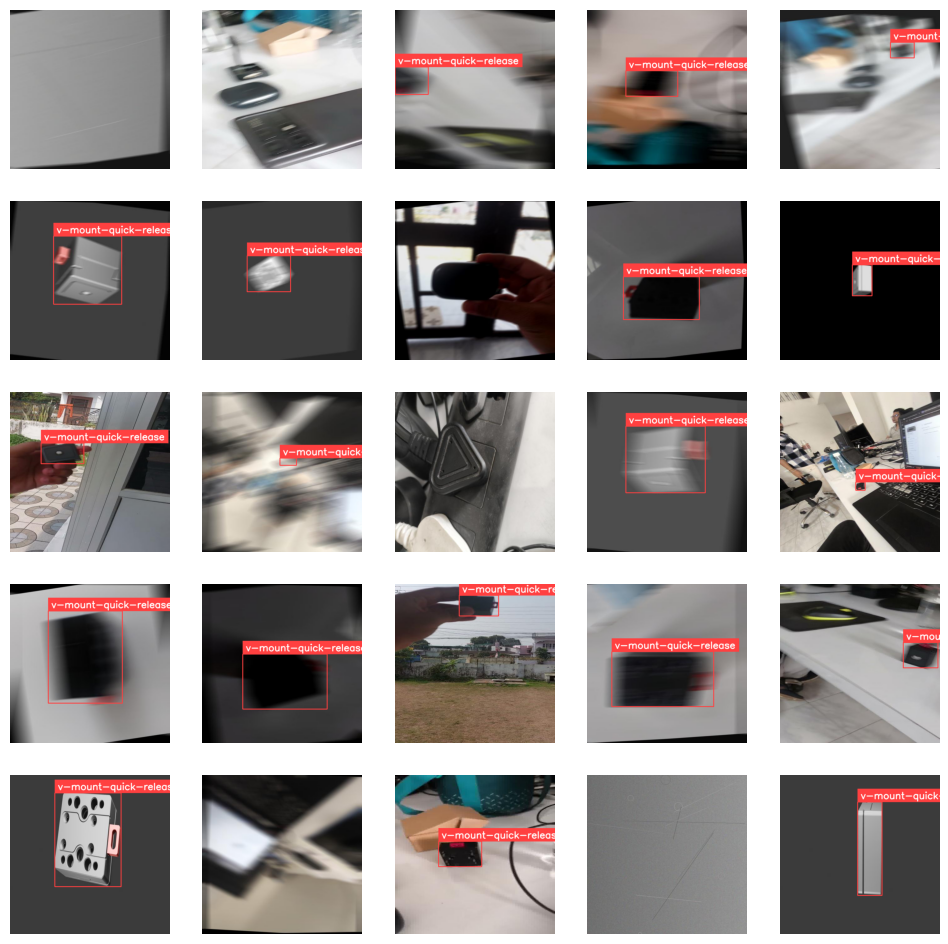

In [10]:
# @title Display dataset sample

GRID_SIZE = 5

def annotate(image, annotations, classes):
    labels = [
        classes[class_id]
        for class_id
        in annotations.class_id
    ]

    bounding_box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator(text_scale=1, text_thickness=2)

    annotated_image = image.copy()
    annotated_image = bounding_box_annotator.annotate(annotated_image, annotations)
    annotated_image = label_annotator.annotate(annotated_image, annotations, labels=labels)
    return annotated_image

annotated_images = []
for i in range(GRID_SIZE * GRID_SIZE):
    _, image, annotations = ds_train[i]
    annotated_image = annotate(image, annotations, ds_train.classes)
    annotated_images.append(annotated_image)

sv.plot_images_grid(
    images=annotated_images,
    grid_size=(GRID_SIZE, GRID_SIZE)
)

### Preprocess the data

To finetune a model, you must preprocess the data you plan to use to match precisely the approach used for the pre-trained model. [AutoImageProcessor](https://huggingface.co/docs/transformers/main/en/model_doc/auto#transformers.AutoImageProcessor) takes care of processing image data to create `pixel_values`, `pixel_mask`, and `labels` that a DETR model can train with. The image processor has some attributes that you won't have to worry about:

- `image_mean = [0.485, 0.456, 0.406 ]`
- `image_std = [0.229, 0.224, 0.225]`

These are the mean and standard deviation used to normalize images during the model pre-training. These values are crucial to replicate when doing inference or finetuning a pre-trained image model.

Instantiate the image processor from the same checkpoint as the model you want to finetune.

In [11]:
IMAGE_SIZE = 480

processor = AutoImageProcessor.from_pretrained(
    CHECKPOINT,
    do_resize=True,
    size={"width": IMAGE_SIZE, "height": IMAGE_SIZE},
)

Before passing the images to the `processor`, apply two preprocessing transformations to the dataset:

- Augmenting images
- Reformatting annotations to meet RT-DETR expectations

First, to make sure the model does not overfit on the training data, you can apply image augmentation with any data augmentation library. Here we use [Albumentations](https://albumentations.ai/docs/). This library ensures that transformations affect the image and update the bounding boxes accordingly.

In [12]:
train_augmentation_and_transform = A.Compose(
    [
        A.Perspective(p=0.1),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(p=0.1),
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=25
    ),
)

valid_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=1
    ),
)

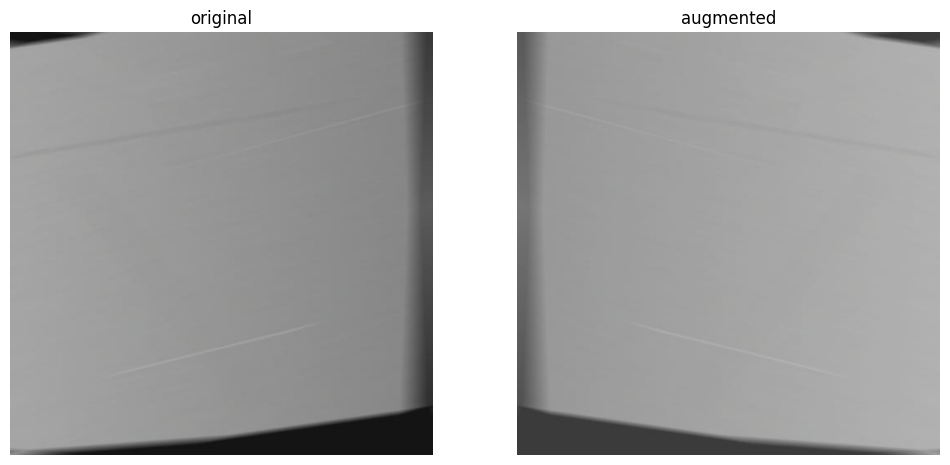

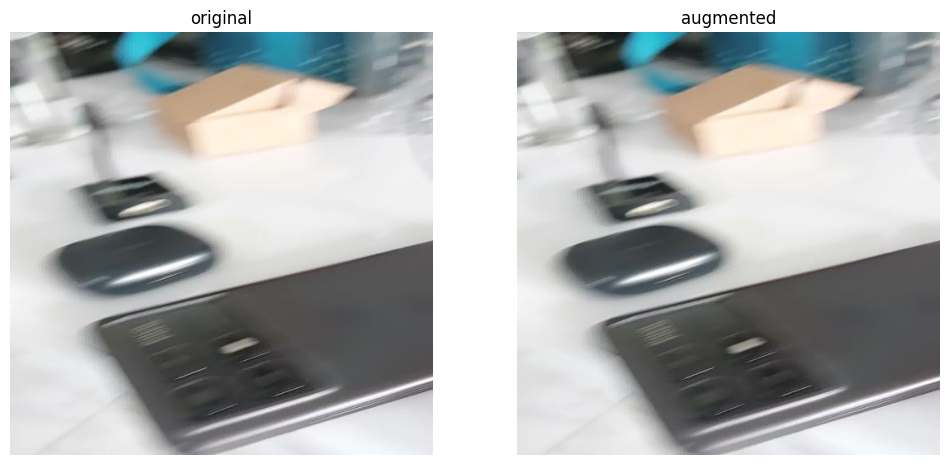

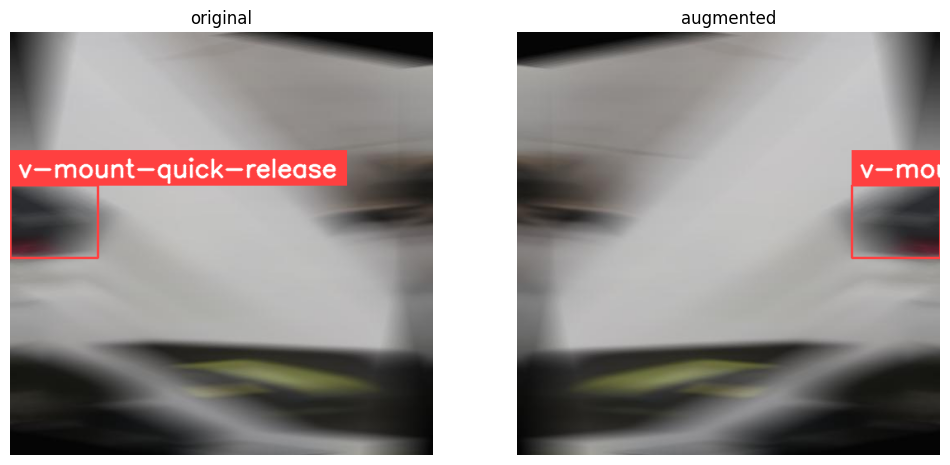

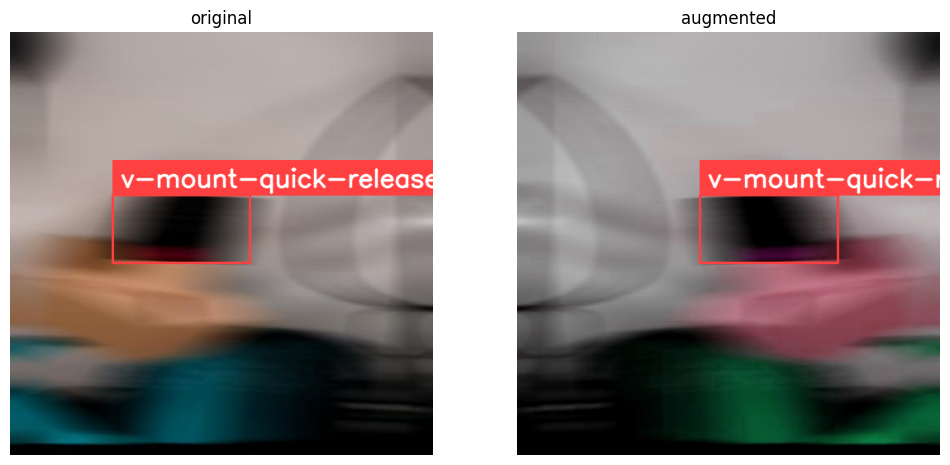

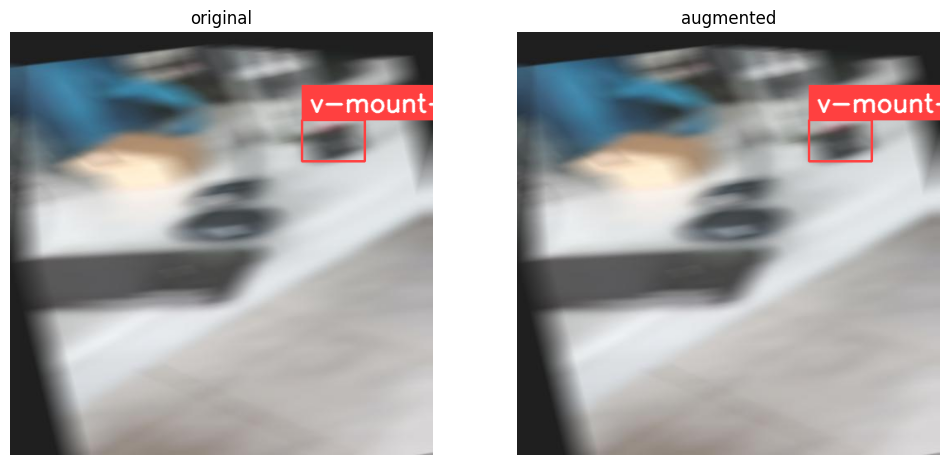

In [14]:
# @title Visualize some augmented images

IMAGE_COUNT = 5

for i in range(IMAGE_COUNT):
    _, image, annotations = ds_train[i]

    output = train_augmentation_and_transform(
        image=image,
        bboxes=annotations.xyxy,
        category=annotations.class_id
    )

    augmented_image = output["image"]
    augmented_annotations = replace(
        annotations,
        xyxy=np.array(output["bboxes"]),
        class_id=np.array(output["category"])
    )

    annotated_images = [
        annotate(image, annotations, ds_train.classes),
        annotate(augmented_image, augmented_annotations, ds_train.classes)
    ]
    sv.plot_images_grid(
        images=annotated_images,
        titles=['original', 'augmented'],
        grid_size=(1, 2) # Display original and augmented images side-by-side
    )

The `processor` expects the annotations to be in the following format: `{'image_id': int, 'annotations': List[Dict]}`, where each dictionary is a COCO object annotation. Let's add a function to reformat annotations for a single example:

In [25]:
class PyTorchDetectionDataset(Dataset):
    def __init__(self, dataset: sv.DetectionDataset, processor, transform: A.Compose = None):
        self.dataset = dataset
        self.processor = processor
        self.transform = transform

    @staticmethod
    def annotations_as_coco(image_id, categories, boxes):
        annotations = []
        for category, bbox in zip(categories, boxes):
            x1, y1, x2, y2 = bbox
            formatted_annotation = {
                "image_id": image_id,
                "category_id": category,
                "bbox": [x1, y1, x2 - x1, y2 - y1],
                "iscrowd": 0,
                "area": (x2 - x1) * (y2 - y1),
            }
            annotations.append(formatted_annotation)

        return {
            "image_id": image_id,
            "annotations": annotations,
        }

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        _, image, annotations = self.dataset[idx]

        # Convert image to RGB numpy array and ensure it's contiguous
        image = image[:, :, ::-1].copy()
        boxes = annotations.xyxy
        categories = annotations.class_id

        if self.transform:
            transformed = self.transform(
                image=image,
                bboxes=boxes,
                category=categories
            )
            image = transformed["image"]
            boxes = transformed["bboxes"]
            categories = transformed["category"]


        formatted_annotations = self.annotations_as_coco(
            image_id=idx, categories=categories, boxes=boxes)
        result = self.processor(
            images=image, annotations=formatted_annotations, return_tensors="pt")

        # Image processor expands batch dimension, lets squeeze it
        result = {k: v[0] for k, v in result.items()}

        return result

Now you can combine the image and annotation transformations to use on a batch of examples:

In [26]:
pytorch_dataset_train = PyTorchDetectionDataset(
    ds_train, processor, transform=train_augmentation_and_transform)
pytorch_dataset_valid = PyTorchDetectionDataset(
    ds_valid, processor, transform=valid_transform)
pytorch_dataset_test = PyTorchDetectionDataset(
    ds_test, processor, transform=valid_transform)

pytorch_dataset_train[15]

{'pixel_values': tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0549, 0.0588, 0.0627],
          [0.0000, 0.0000, 0.0000,  ..., 0.0549, 0.0588, 0.0588],
          [0.0000, 0.0000, 0.0000,  ..., 0.0549, 0.0549, 0.0549],
          ...,
          [0.0000, 0.0078, 0.0196,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0039, 0.0157,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0039, 0.0157,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.0000, 0.0000, 0.0000,  ..., 0.0549, 0.0588, 0.0627],
          [0.0000, 0.0000, 0.0000,  ..., 0.0549, 0.0588, 0.0588],
          [0.0000, 0.0000, 0.0000,  ..., 0.0549, 0.0549, 0.0549],
          ...,
          [0.0000, 0.0078, 0.0196,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0039, 0.0157,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0039, 0.0157,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.0000, 0.0000, 0.0000,  ..., 0.0549, 0.0588, 0.0627],
          [0.0000, 0.0000, 0.0000,  ..., 0.0549, 0.0588, 0.0588],
          [0.0000, 0.000

You have successfully augmented the images and prepared their annotations. In the final step, create a custom collate_fn to batch images together.

In [27]:
def collate_fn(batch):
    data = {}
    data["pixel_values"] = torch.stack([x["pixel_values"] for x in batch])
    data["labels"] = [x["labels"] for x in batch]
    return data

## Preparing function to compute mAP

In [28]:
id2label = {id: label for id, label in enumerate(ds_train.classes)}
label2id = {label: id for id, label in enumerate(ds_train.classes)}


@dataclass
class ModelOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor


class MAPEvaluator:

    def __init__(self, image_processor, threshold=0.00, id2label=None):
        self.image_processor = image_processor
        self.threshold = threshold
        self.id2label = id2label

    def collect_image_sizes(self, targets):
        """Collect image sizes across the dataset as list of tensors with shape [batch_size, 2]."""
        image_sizes = []
        for batch in targets:
            batch_image_sizes = torch.tensor(np.array([x["size"] for x in batch]))
            image_sizes.append(batch_image_sizes)
        return image_sizes

    def collect_targets(self, targets, image_sizes):
        post_processed_targets = []
        for target_batch, image_size_batch in zip(targets, image_sizes):
            for target, (height, width) in zip(target_batch, image_size_batch):
                boxes = target["boxes"]
                boxes = sv.xcycwh_to_xyxy(boxes)
                boxes = boxes * np.array([width, height, width, height])
                boxes = torch.tensor(boxes)
                labels = torch.tensor(target["class_labels"])
                post_processed_targets.append({"boxes": boxes, "labels": labels})
        return post_processed_targets

    def collect_predictions(self, predictions, image_sizes):
        post_processed_predictions = []
        for batch, target_sizes in zip(predictions, image_sizes):
            batch_logits, batch_boxes = batch[1], batch[2]
            output = ModelOutput(logits=torch.tensor(batch_logits), pred_boxes=torch.tensor(batch_boxes))
            post_processed_output = self.image_processor.post_process_object_detection(
                output, threshold=self.threshold, target_sizes=target_sizes
            )
            post_processed_predictions.extend(post_processed_output)
        return post_processed_predictions

    @torch.no_grad()
    def __call__(self, evaluation_results):

        predictions, targets = evaluation_results.predictions, evaluation_results.label_ids

        image_sizes = self.collect_image_sizes(targets)
        post_processed_targets = self.collect_targets(targets, image_sizes)
        post_processed_predictions = self.collect_predictions(predictions, image_sizes)

        evaluator = MeanAveragePrecision(box_format="xyxy", class_metrics=True)
        evaluator.warn_on_many_detections = False
        evaluator.update(post_processed_predictions, post_processed_targets)

        metrics = evaluator.compute()

        # Replace list of per class metrics with separate metric for each class
        classes = metrics.pop("classes")
        map_per_class = metrics.pop("map_per_class")
        mar_100_per_class = metrics.pop("mar_100_per_class")
        for class_id, class_map, class_mar in zip(classes, map_per_class, mar_100_per_class):
            class_name = id2label[class_id.item()] if id2label is not None else class_id.item()
            metrics[f"map_{class_name}"] = class_map
            metrics[f"mar_100_{class_name}"] = class_mar

        metrics = {k: round(v.item(), 4) for k, v in metrics.items()}

        return metrics

eval_compute_metrics_fn = MAPEvaluator(image_processor=processor, threshold=0.01, id2label=id2label)

## Training the detection model

You have done most of the heavy lifting in the previous sections, so now you are ready to train your model! The images in this dataset are still quite large, even after resizing. This means that finetuning this model will require at least one GPU.

Training involves the following steps:

- Load the model with [`AutoModelForObjectDetection`](https://huggingface.co/docs/transformers/main/en/model_doc/auto#transformers.AutoModelForObjectDetection) using the same checkpoint as in the preprocessing.
- Define your training hyperparameters in [`TrainingArguments`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.TrainingArguments).
- Pass the training arguments to [`Trainer`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer) along with the model, dataset, image processor, and data collator.
- Call [`train()`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer.train) to finetune your model.

When loading the model from the same checkpoint that you used for the preprocessing, remember to pass the `label2id` and `id2label` maps that you created earlier from the dataset's metadata. Additionally, we specify `ignore_mismatched_sizes=True` to replace the existing classification head with a new one.

In [29]:
model = AutoModelForObjectDetection.from_pretrained(
    CHECKPOINT,
    id2label=id2label,
    label2id=label2id,
    anchor_image_size=None,
    ignore_mismatched_sizes=True,
)

Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

RTDetrForObjectDetection LOAD REPORT from: PekingU/rtdetr_r50vd_coco_o365
Key                                                 | Status   |                                                                                        
----------------------------------------------------+----------+----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([2])          
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([2, 256])
model.denoising_class_embed.weight                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([3, 256])
model.enc_score_head.weight                         | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([2, 256])
model.en

In the [`TrainingArguments`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.TrainingArguments) use `output_dir` to specify where to save your model, then configure hyperparameters as you see fit. For `num_train_epochs=10` training will take about 15 minutes in Google Colab T4 GPU, increase the number of epoch to get better results.

Important notes:

- Do not remove unused columns because this will drop the image column. Without the image column, you can't create `pixel_values`. For this reason, set `remove_unused_columns` to `False`.
- Set `eval_do_concat_batches=False` to get proper evaluation results. Images have different number of target boxes, if batches are concatenated we will not be able to determine which boxes belongs to particular image.

In [30]:
training_args = TrainingArguments(
    output_dir=f"{dataset.name.replace(' ', '-')}-finetune",
    num_train_epochs=25,
    max_grad_norm=0.1,
    learning_rate=5e-5,
    warmup_steps=300,
    per_device_train_batch_size=16,
    dataloader_num_workers=2,
    metric_for_best_model="eval_map",
    greater_is_better=True,
    load_best_model_at_end=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    eval_do_concat_batches=False,
)

Finally, bring everything together, and call [`train()`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer.train):

In [31]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=pytorch_dataset_train,
    eval_dataset=pytorch_dataset_valid,
    data_collator=collate_fn,
    compute_metrics=eval_compute_metrics_fn,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Map,Map 50,Map 75,Map Small,Map Medium,Map Large,Mar 1,Mar 10,Mar 100,Mar Small,Mar Medium,Mar Large,Map V-mount-quick-release,Mar 100 V-mount-quick-release
1,No log,19.142929,0.366600,0.424300,0.421300,0.357000,0.425000,0.476500,0.774700,0.921800,0.928700,0.730800,0.902700,0.979500,0.366600,0.928700
2,No log,5.228311,0.886300,0.964900,0.958300,0.759400,0.854000,0.939300,0.898900,0.933900,0.937400,0.846200,0.904100,0.978400,0.886300,0.937400
3,108.143023,4.211362,0.895700,0.977600,0.946900,0.822200,0.849300,0.945100,0.906300,0.944800,0.948300,0.900000,0.920500,0.978400,0.895700,0.948300
4,108.143023,3.439662,0.919000,0.987300,0.978400,0.830600,0.876400,0.961600,0.926400,0.939100,0.939700,0.907700,0.901400,0.976100,0.919000,0.939700
5,108.143023,3.296320,0.927200,0.982200,0.982200,0.867400,0.906700,0.957800,0.944300,0.946000,0.946000,0.907700,0.920500,0.972700,0.927200,0.946000
6,10.012592,2.961811,0.932700,0.989500,0.979200,0.883800,0.896500,0.967900,0.942500,0.943100,0.943100,0.900000,0.909600,0.977300,0.932700,0.943100
7,10.012592,2.915626,0.933400,0.988900,0.988900,0.892300,0.905400,0.960600,0.943100,0.943700,0.943700,0.915400,0.916400,0.970500,0.933400,0.943700
8,10.012592,3.006765,0.931500,0.986500,0.978800,0.857100,0.903400,0.965000,0.939700,0.944800,0.944800,0.892300,0.917800,0.975000,0.931500,0.944800
9,8.876575,2.952940,0.923600,0.987400,0.977300,0.852400,0.883600,0.965800,0.935600,0.937900,0.937900,0.900000,0.900000,0.975000,0.923600,0.937900
10,8.876575,2.801494,0.931200,0.984300,0.978600,0.877000,0.902600,0.963800,0.944300,0.944800,0.944800,0.900000,0.919200,0.972700,0.931200,0.944800


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.aifi.0.layers.0.self_attn.k_proj.weight', 'model.encoder.aifi.0.layers.0.self_attn.k_proj.bias', 'model.encoder.aifi.0.layers.0.self_attn.v_proj.weight', 'model.encoder.aifi.0.layers.0.self_attn.v_proj.bias', 'model.encoder.aifi.0.layers.0.self_attn.q_proj.weight', 'model.encoder.aifi.0.layers.0.self_attn.q_proj.bias', 'model.encoder.aifi.0.layers.0.self_attn.o_proj.weight', 'model.encoder.aifi.0.layers.0.self_attn.o_proj.bias', 'model.encoder.aifi.0.layers.0.self_attn_layer_norm.weight', 'model.encoder.aifi.0.layers.0.self_attn_layer_norm.bias', 'model.encoder.aifi.0.layers.0.mlp.fc1.weight', 'model.encoder.aifi.0.layers.0.mlp.fc1.bias', 'model.encoder.aifi.0.layers.0.mlp.fc2.weight', 'model.encoder.aifi.0.layers.0.mlp.fc2.bias', 'model.encoder.aifi.0.layers.0.final_layer_norm.weight', 'model.encoder.aifi.0.layers.0.final_layer_norm.bias', 'model.decoder.layers.0.self_attn.o_proj.weight', 'model.decoder.layers.0.s

TrainOutput(global_step=4175, training_loss=19.84865360100112, metrics={'train_runtime': 7232.2675, 'train_samples_per_second': 9.198, 'train_steps_per_second': 0.577, 'total_flos': 1.178897230063872e+19, 'train_loss': 19.84865360100112, 'epoch': 25.0})

In [ ]:
!zip /content

## Evaluate

In [32]:
# @title Collect predictions

targets = []
predictions = []

for i in range(len(ds_test)):
    path, sourece_image, annotations = ds_test[i]

    image = Image.open(path)
    inputs = processor(image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    w, h = image.size
    results = processor.post_process_object_detection(
        outputs, target_sizes=[(h, w)], threshold=0.3)

    detections = sv.Detections.from_transformers(results[0])

    targets.append(annotations)
    predictions.append(detections)

In [33]:
# @title Calculate mAP
mean_average_precision = sv.MeanAveragePrecision.from_detections(
    predictions=predictions,
    targets=targets,
)

print(f"map50_95: {mean_average_precision.map50_95:.2f}")
print(f"map50: {mean_average_precision.map50:.2f}")
print(f"map75: {mean_average_precision.map75:.2f}")

map50_95: 0.97
map50: 0.99
map75: 0.99


MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.


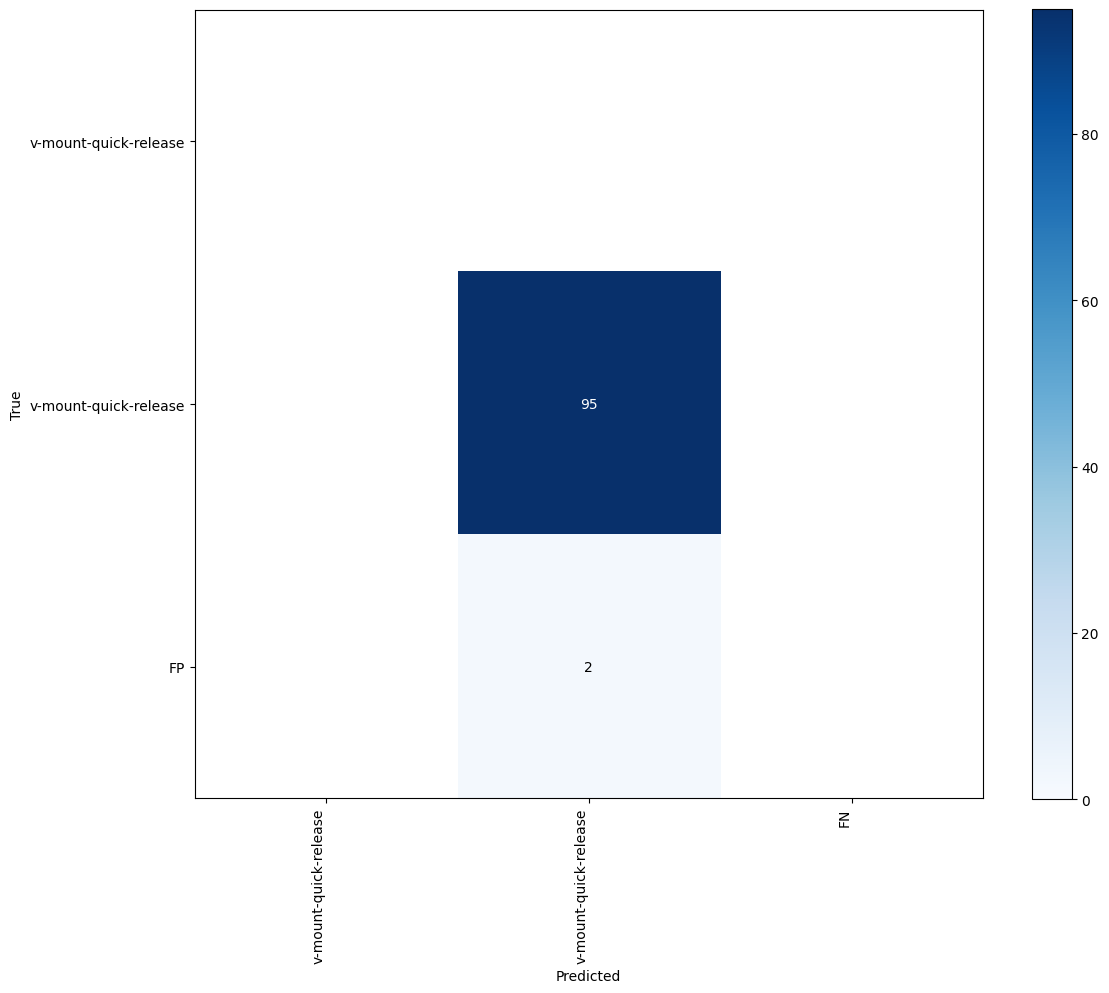

In [34]:
# @title Calculate Confusion Matrix
confusion_matrix = sv.ConfusionMatrix.from_detections(
    predictions=predictions,
    targets=targets,
    classes=ds_test.classes
)

_ = confusion_matrix.plot()

## Save fine-tuned model on hard drive

In [35]:
model.save_pretrained("/content/rt-detr/")
processor.save_pretrained("/content/rt-detr/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['/content/rt-detr/preprocessor_config.json']

In [36]:
!zip /content/rtdetr.zip /content/rt-detr/

  adding: content/rt-detr/ (stored 0%)


In [40]:
!zip -r /content/DRDL-Object--finetune_1.zip /content/DRDL-Object--finetune


  adding: content/DRDL-Object--finetune/ (stored 0%)
  adding: content/DRDL-Object--finetune/checkpoint-2004/ (stored 0%)
  adding: content/DRDL-Object--finetune/checkpoint-2004/trainer_state.json (deflated 80%)
  adding: content/DRDL-Object--finetune/checkpoint-2004/model.safetensors (deflated 7%)
  adding: content/DRDL-Object--finetune/checkpoint-2004/scheduler.pt (deflated 61%)
  adding: content/DRDL-Object--finetune/checkpoint-2004/training_args.bin (deflated 53%)
  adding: content/DRDL-Object--finetune/checkpoint-2004/optimizer.pt (deflated 8%)
  adding: content/DRDL-Object--finetune/checkpoint-2004/config.json (deflated 64%)
  adding: content/DRDL-Object--finetune/checkpoint-2004/rng_state.pth (deflated 26%)
  adding: content/DRDL-Object--finetune/checkpoint-4175/ (stored 0%)
  adding: content/DRDL-Object--finetune/checkpoint-4175/trainer_state.json (deflated 84%)
  adding: content/DRDL-Object--finetune/checkpoint-4175/model.safetensors (deflated 7%)
  adding: content/DRDL-Object

## Inference with fine-tuned RT-DETR model

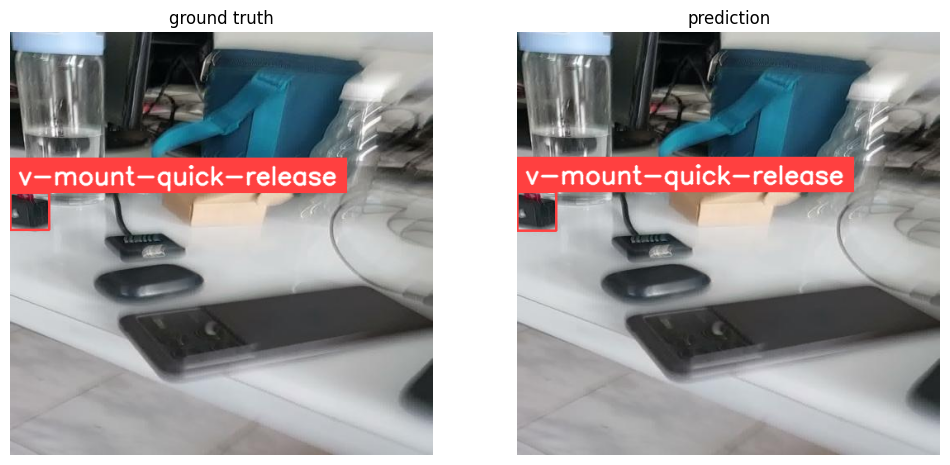

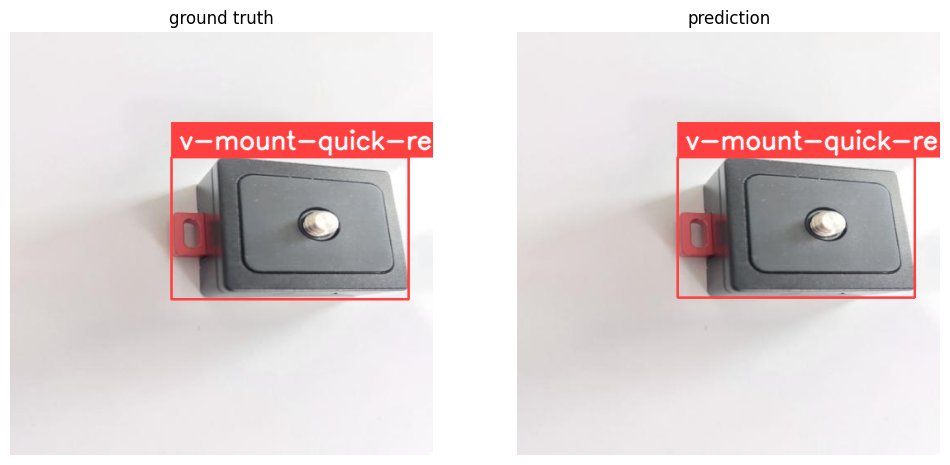

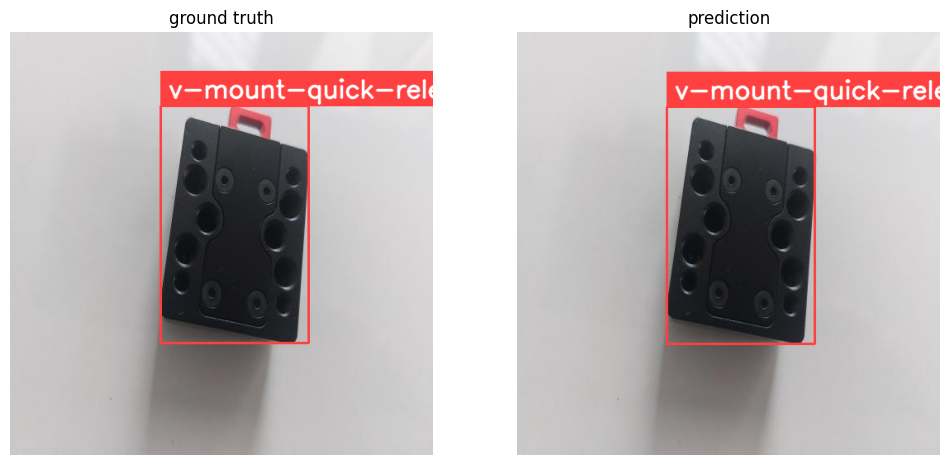

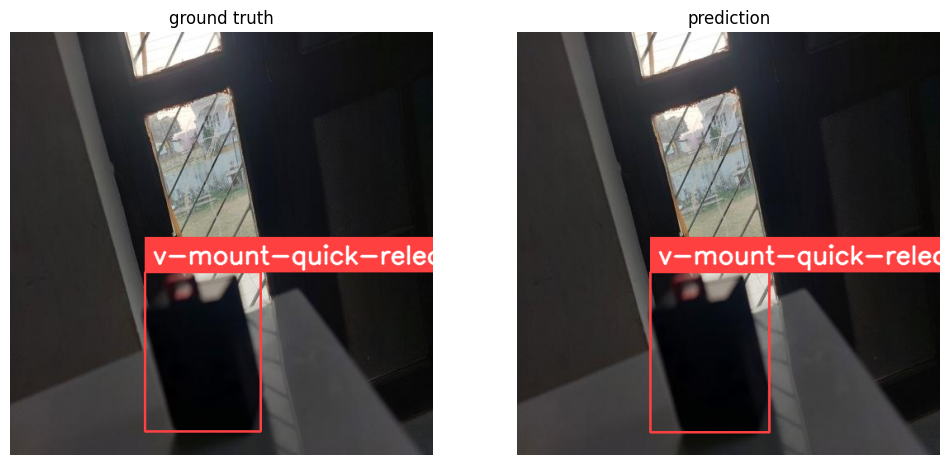

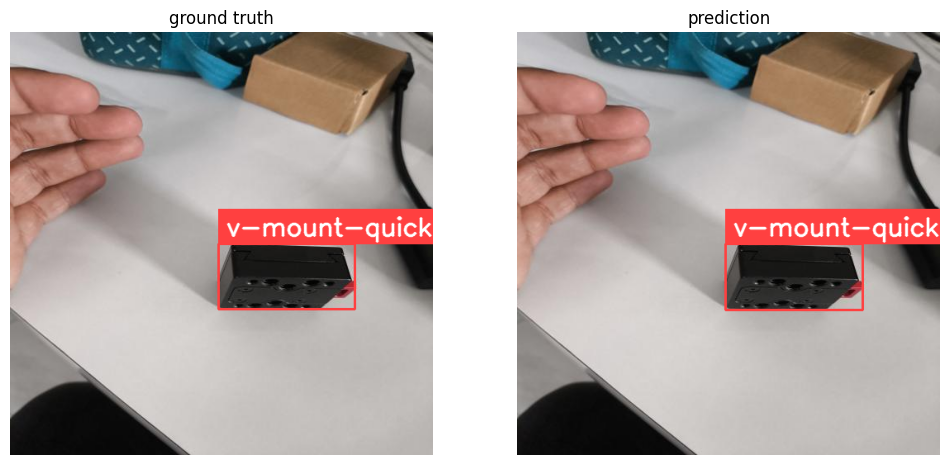

In [42]:
IMAGE_COUNT = 5

for i in range(IMAGE_COUNT):
    path, sourece_image, annotations = ds_test[i]

    image = Image.open(path)
    inputs = processor(image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    w, h = image.size
    results = processor.post_process_object_detection(
        outputs, target_sizes=[(h, w)], threshold=0.3)

    detections = sv.Detections.from_transformers(results[0]).with_nms(threshold=0.1)

    annotated_images = [
        annotate(sourece_image, annotations, ds_train.classes),
        annotate(sourece_image, detections, ds_train.classes)
    ]
    sv.plot_images_grid(
        images=annotated_images,
        titles=['ground truth', 'prediction'],
        grid_size=(1, 2) # Display original and prediction images side-by-side
    )

In [44]:
import torch
import supervision as sv
from PIL import Image

false_positive_indices = []

for i in range(len(ds_test)):

    path, source_image, annotations = ds_test[i]

    image = Image.open(path)
    inputs = processor(image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    w, h = image.size

    results = processor.post_process_object_detection(
        outputs,
        target_sizes=[(h, w)],
        threshold=0.3
    )

    detections = sv.Detections.from_transformers(results[0]).with_nms(threshold=0.1)

    gt = annotations # 'annotations' is already an sv.Detections object

    if len(detections) > 0 and len(gt) == 0:
        false_positive_indices.append(i)

print("False positive images:", false_positive_indices)

False positive images: [16, 29]


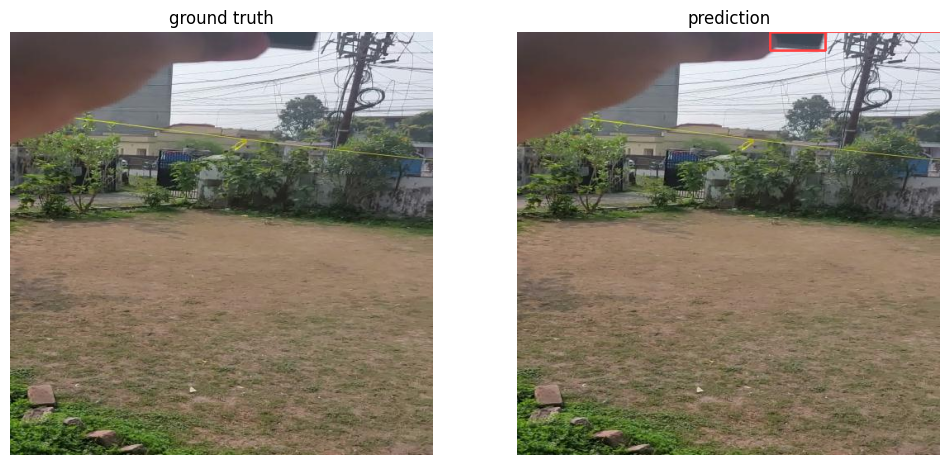

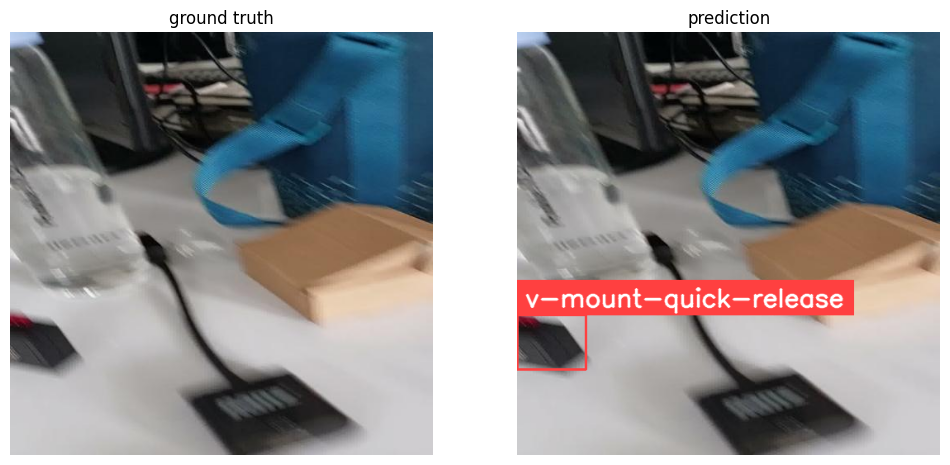

In [45]:
for i in false_positive_indices:

    path, source_image, annotations = ds_test[i]

    image = Image.open(path)
    inputs = processor(image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    w, h = image.size

    results = processor.post_process_object_detection(
        outputs,
        target_sizes=[(h, w)],
        threshold=0.3
    )

    detections = sv.Detections.from_transformers(results[0]).with_nms(threshold=0.1)

    annotated_images = [
        annotate(source_image, annotations, ds_train.classes),
        annotate(source_image, detections, ds_train.classes)
    ]

    sv.plot_images_grid(
        images=annotated_images,
        titles=['ground truth', 'prediction'],
        grid_size=(1,2)
    )